# Problem 2.1

> Goal: study logistic regression, optimization, and regularization on the provided binary dataset.

## 2.1.1 Loss Surface for Logistic Regression

> Task: Load `data.csv` and visualize the loss surface $J(\mathbf{w})$ based on the regularized binary cross-entropy objective. Compare the cases $\lambda = 0$ and $\lambda = 10^{-2}$.

> Pipeline schematic
1. Load the dataset and split it into inputs $X$ and labels $y$.
2. Define the sigmoid function and the regularized loss.
3. Evaluate the loss on a grid of weight vectors $(w_0, w_1)$.
4. Plot the two loss surfaces and compare how regularization changes the geometry.

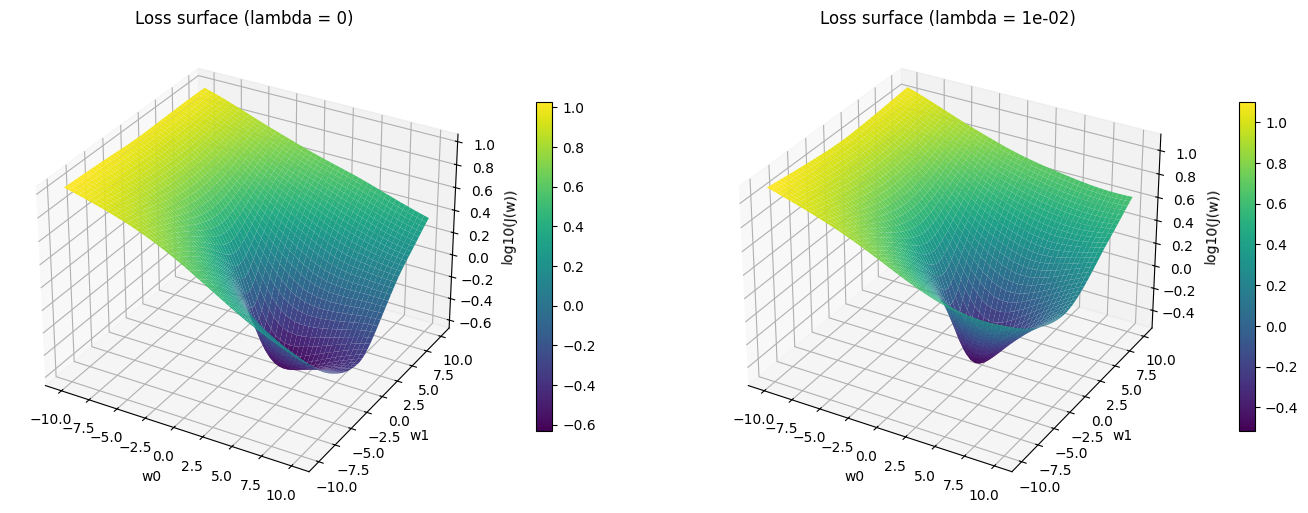

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: load the 2D binary classification dataset.
# We keep the two input coordinates as the weight-matched features X and the last column as labels y.
data = np.loadtxt("data/data.csv", delimiter=",", skiprows=1)
X = data[:, :2]
y = data[:, 2]

# Step 2: define the model output.
# The sigmoid is required because the loss is binary cross-entropy for logistic regression.
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Step 3: define the regularized logistic loss.
# We clip probabilities to avoid log(0), which would make the loss numerically unstable.
def compute_loss(X, y, w, lam):
    z = X @ w
    y_hat = sigmoid(z)

    eps = 1e-9
    y_hat = np.clip(y_hat, eps, 1 - eps)

    bce = -(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    return np.mean(bce) + lam * np.sum(w**2)

# Step 4: build a grid over the two weight components.
# The grid lets us evaluate the loss landscape rather than just a single optimization path.
w0_vals = np.linspace(-10, 10, 50)
w1_vals = np.linspace(-10, 10, 50)
W0, W1 = np.meshgrid(w0_vals, w1_vals)
lambda_vals = [0, 1e-2]

fig = plt.figure(figsize=(14, 5), constrained_layout=True)

for plot_index, lam in enumerate(lambda_vals, start=1):
    loss_surface = np.zeros_like(W0)

    for i in range(W0.shape[0]):
        for j in range(W0.shape[1]):
            w = np.array([W0[i, j], W1[i, j]])
            loss_surface[i, j] = compute_loss(X, y, w, lam)

    # We plot log10(J(w)) so both low-loss and high-loss regions remain visible.
    axis = fig.add_subplot(1, 2, plot_index, projection="3d")
    surface = axis.plot_surface(
        W0,
        W1,
        np.log10(loss_surface),
        cmap="viridis",
        linewidth=0,
        antialiased=True,
    )
    fig.colorbar(surface, ax=axis, shrink=0.7, pad=0.1)
    axis.set_xlabel("w0")
    axis.set_ylabel("w1")
    axis.set_zlabel("log10(J(w))")
    axis.set_title(
        f"Loss surface (lambda = {lam:.0e})" if lam else "Loss surface (lambda = 0)"
    )

plt.show()

## 2.1.2 Analytical Gradient

> Task: Derive the analytical expression of the gradient $\nabla_{\mathbf{w}} L(\mathbf{w}, \hat y^{(i)}, y^{(i)})$ for the binary cross-entropy loss in Equation (2.1.4).

The full derivation is written in the report.

## 2.1.3 Batch Gradient Descent (BGD)

> Task: Use the result from 2.1.2 to implement batch gradient descent for the regularized logistic regressor in Equation (2.1.4). Plot $J(\mathbf{w})$ over iterations $k = 1, \dots, K$ and visualize the trajectory of the weight estimates $\hat{\mathbf{w}}^{(k)}$.

> Pipeline schematic
1. Reuse the logistic loss and gradient definitions.
2. Initialize the weights and choose the optimization hyperparameters.
3. Run BGD updates using the full dataset at every step.
4. Store both the loss values and the weight history.
5. Plot convergence in objective space and in parameter space.

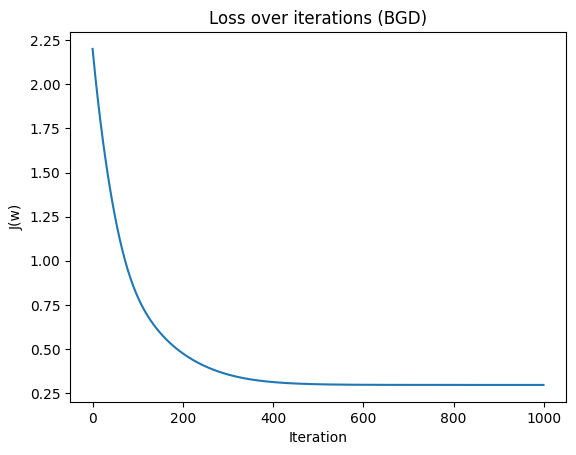

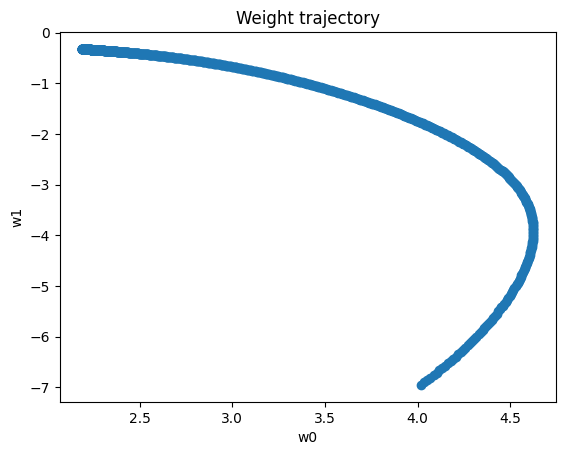

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: define the logistic model again inside this self-contained cell.
# Keeping each implementation self-contained makes the notebook easier to rerun from arbitrary points.
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Step 2: define the regularized objective that BGD will minimize.
# The clip keeps the logarithm well-defined even when probabilities get very close to 0 or 1.
def compute_loss(X, y, w, lam):
    z = X @ w
    y_hat = sigmoid(z)

    eps = 1e-9
    y_hat = np.clip(y_hat, eps, 1 - eps)

    bce = -(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    return np.mean(bce) + lam * np.sum(w**2)

# Step 3: choose optimization hyperparameters.
# K controls the number of updates, alpha is the learning rate, and lam is the L2 penalty strength.
K = 1000
alpha = 1e-1
lam = 1e-2

# Step 4: initialize the weights exactly as requested by the exercise.
# Using the prescribed initialization makes results directly comparable across methods.
w = np.array([4.0, -7.0])

# Step 5: store diagnostic information during optimization.
# We save both the scalar objective and the parameter path to visualize convergence from two perspectives.
loss_history = []
w_history = []

# Step 6: run batch gradient descent.
# Batch means every gradient uses the full dataset at each iteration.
for k in range(K):
    z = X @ w
    y_hat = sigmoid(z)

    # We evaluate the current objective before the update so the history reflects the actual iterate.
    loss = compute_loss(X, y, w, lam)

    # The gradient combines the data term and the derivative of the L2 regularizer.
    error = y_hat - y
    grad = (X.T @ error) / len(y) + 2 * lam * w

    # Standard gradient descent update.
    w = w - alpha * grad

    loss_history.append(loss)
    w_history.append(w.copy())

# Step 7: visualize the objective value over iterations.
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("J(w)")
plt.title("Loss over iterations (BGD)")
plt.show()

# Step 8: visualize the trajectory of the weights in parameter space.
w_history = np.array(w_history)

plt.plot(w_history[:, 0], w_history[:, 1], marker="o")
plt.xlabel("w0")
plt.ylabel("w1")
plt.title("Weight trajectory")
plt.show()

## 2.1.4 Stochastic Gradient Descent (SGD)

> Task: Repeat 2.1.3 with stochastic gradient descent using the same configuration. Compare the BGD and SGD plots, compute the number of epochs for both methods, and discuss which variant is preferable for large datasets.

> Pipeline schematic
1. Keep the same model, loss, and initialization as in BGD.
2. Replace full-batch gradients with single-sample updates.
3. Track the global loss after each stochastic update.
4. Compare the noise pattern in the optimization path with BGD.
5. Relate the number of parameter updates to the number of epochs.

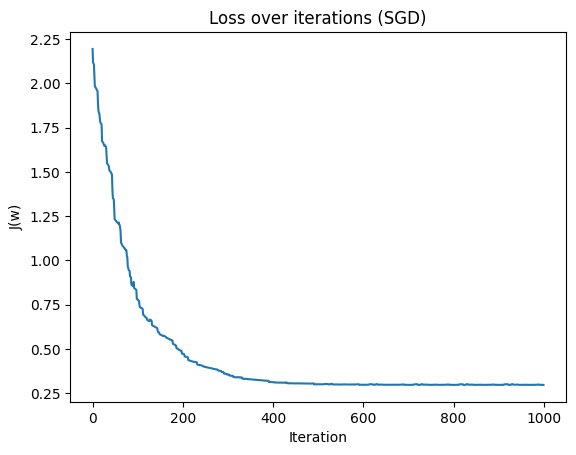

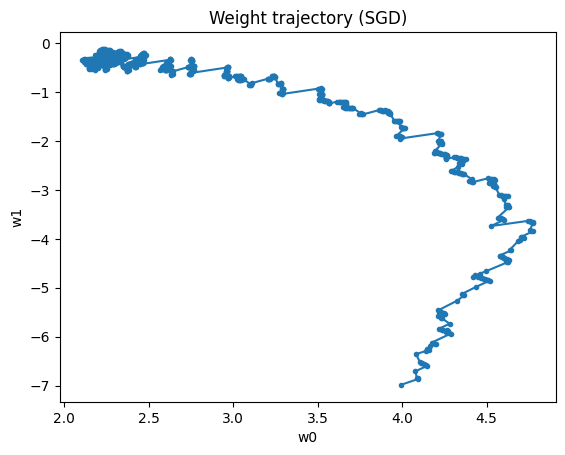

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: reuse the same sigmoid and loss as in the BGD cell.
# This keeps the optimization comparison fair because only the update rule changes.
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(X, y, w, lam):
    z = X @ w
    y_hat = sigmoid(z)

    eps = 1e-9
    y_hat = np.clip(y_hat, eps, 1 - eps)

    bce = -(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    return np.mean(bce) + lam * np.sum(w**2)

# Step 2: keep the same optimization hyperparameters as in BGD.
K = 1000
alpha = 1e-1
lam = 1e-2

# Step 3: use the same initialization to make the trajectories directly comparable.
w = np.array([4.0, -7.0])

# Step 4: prepare histories for the loss and the parameter updates.
loss_history = []
w_history = []

# Step 5: store dataset size because SGD updates only one sample at a time.
N = len(y)

# Step 6: run stochastic gradient descent.
# We cycle through samples deterministically via k % N so the notebook is reproducible.
for k in range(K):
    i = k % N
    x_i = X[i]
    y_i = y[i]

    # SGD forms the prediction using only the selected sample.
    z = np.dot(w, x_i)
    y_hat = sigmoid(z)

    # The stochastic gradient is a one-sample approximation of the full gradient.
    error = y_hat - y_i
    grad = error * x_i + 2 * lam * w

    # The update is applied immediately after seeing one sample.
    w = w - alpha * grad

    # We still track the global objective so the plot remains comparable to BGD.
    loss = compute_loss(X, y, w, lam)
    loss_history.append(loss)
    w_history.append(w.copy())

# Step 7: visualize the noisy but generally decreasing SGD objective path.
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("J(w)")
plt.title("Loss over iterations (SGD)")
plt.show()

# Step 8: visualize the weight path, which is typically more irregular than in BGD.
w_history = np.array(w_history)

plt.plot(w_history[:, 0], w_history[:, 1], marker="o", markersize=3)
plt.xlabel("w0")
plt.ylabel("w1")
plt.title("Weight trajectory (SGD)")
plt.show()

# Step 9: compare the number of epochs covered by BGD and SGD.
# One BGD iteration uses the full dataset, while one SGD iteration uses only one sample.
bgd_epochs = K
sgd_epochs = K / N

print(f"BGD epochs after {K} iterations: {bgd_epochs:.0f}")
print(f"SGD epochs after {K} iterations: {sgd_epochs:.2f}")
print("BGD makes one full pass over the data per update, while SGD only processes one sample per update.")

## 2.1.5 Automatic Differentiation with JAX

> Task: Replace the manual gradient in the BGD implementation by `jax.grad` (or `jax.value_and_grad`), then visualize the optimization process and verify that the results are equivalent to the manual implementation.

> Pipeline schematic
1. Express the loss directly in JAX so it is differentiable by the library.
2. Use automatic differentiation to obtain the gradient function.
3. Re-run the same BGD loop with the auto-diff gradient.
4. Compare the loss curve and weight trajectory against the manual version.
5. Confirm that the numerical behavior is equivalent.

In [9]:
# JAX is used only in the next cell for automatic differentiation.
# Installing it here keeps the dependency step explicit in the notebook pipeline.
%pip install jax

  Using cached jax-0.9.2-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.9.2-cp313-cp313-win_amd64.whl.metadata (1.4 kB)
  Using cached ml_dtypes-0.5.4-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
Using cached jax-0.9.2-py3-none-any.whl (3.1 MB)
Using cached jaxlib-0.9.2-cp313-cp313-win_amd64.whl (62.8 MB)
Using cached ml_dtypes-0.5.4-cp313-cp313-win_amd64.whl (212 kB)
Using cached opt_einsum-3.4.0-py3-none-any.whl (71 kB)

   ---------------------------------------- 0/4 [opt_einsum]
   ---------------------------------------- 0/4 [opt_einsum]
   ---------------------------------------- 0/4 [opt_einsum]
   ---------------------------------------- 0/4 [opt_einsum]
   ---------------------------------------- 0/4 [opt_einsum]
   ---------------------------------------- 0/4 [opt_einsum]
   ---------------------------------------- 0/4 [opt_einsum]
   ---------------------------------------- 0/4 [opt_einsum]
   -----

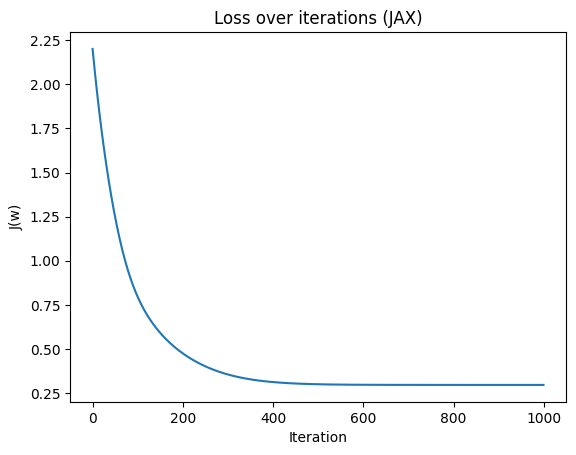

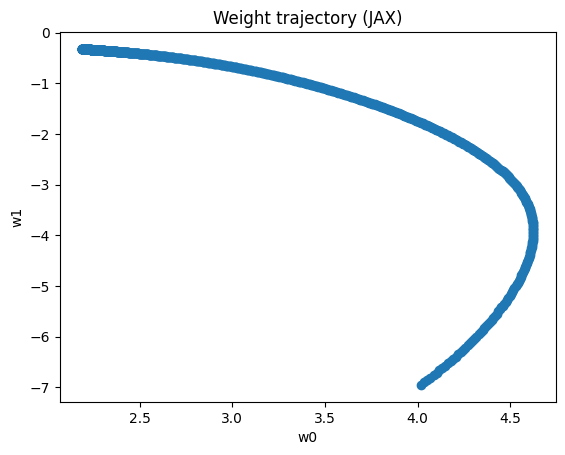

In [12]:
import jax.numpy as jnp
from jax import grad
import numpy as np
import matplotlib.pyplot as plt

# Step 1: convert the already loaded NumPy arrays to JAX arrays.
# We keep float32 explicitly because JAX often defaults to that dtype and we want predictable behavior.
X_jax = jnp.array(X, dtype=jnp.float32)
y_jax = jnp.array(y, dtype=jnp.float32)

# Step 2: define the model output in JAX.
# The function must be written with JAX operations so automatic differentiation can trace it.
def sigmoid(z):
    return 1 / (1 + jnp.exp(-z))

# Step 3: set the same hyperparameters as in the manual BGD implementation.
K = 1000
alpha = 1e-1
lam = 1e-2

# Step 4: define the loss entirely in JAX.
# Using eps = 1e-7 is more stable here because the cell runs in float32 precision.
def compute_loss_jax(w):
    z = X_jax @ w
    y_hat = sigmoid(z)

    eps = 1e-7
    y_hat = jnp.clip(y_hat, eps, 1 - eps)

    bce = -(y_jax * jnp.log(y_hat) + (1 - y_jax) * jnp.log(1 - y_hat))
    return jnp.mean(bce) + lam * jnp.sum(w**2)

# Step 5: let JAX build the gradient function automatically from the loss definition.
# This is the main reason for using JAX here: no manual derivative code is needed.
grad_fn = grad(compute_loss_jax)

# Step 6: initialize the weights and prepare diagnostic histories.
w = jnp.array([4.0, -7.0], dtype=jnp.float32)
loss_history = []
w_history = []

# Step 7: run the same BGD loop as before, but now with auto-diff gradients.
for k in range(K):
    loss = compute_loss_jax(w)
    grad_val = grad_fn(w)

    w = w - alpha * grad_val

    # We convert JAX arrays to Python/NumPy types for plotting with Matplotlib.
    loss_history.append(float(loss))
    w_history.append(np.array(w))

# Step 8: plot the objective history and the parameter trajectory, just like in the manual version.
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("J(w)")
plt.title("Loss over iterations (JAX)")
plt.show()

w_history = np.array(w_history)

plt.plot(w_history[:, 0], w_history[:, 1], marker="o")
plt.xlabel("w0")
plt.ylabel("w1")
plt.title("Weight trajectory (JAX)")
plt.show()

# Problem 2.2

> Goal: study support vector classifiers, margins, feature transformations, and kernel methods.

## 2.2.1 Hinge Loss Visualization

> Task: Visualize the SVC loss from Equation (2.2.2) for a single sample as a function of the soft prediction $\hat y = \mathbf{x}^\top \mathbf{w} + b$ with $\lambda = 0$. Distinguish the cases $y = \pm 1$ and compare the objective to the Perceptron loss.

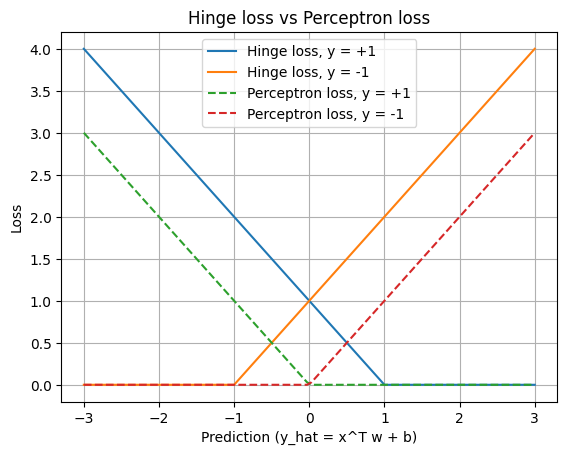

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: build a range of soft predictions y_hat = x^T w + b.
# We study the loss as a function of the score itself, not of the original features.
y_hat = np.linspace(-3, 3, 100)

# Step 2: compute the hinge loss for the positive and negative label cases separately.
# The max(0, ·) form is exactly what creates the margin-based behavior of SVCs.
hinge_pos = np.maximum(0, 1 - y_hat)
hinge_neg = np.maximum(0, 1 + y_hat)

# Step 3: compute the Perceptron loss for the same two label cases.
# The Perceptron only penalizes wrong-sign predictions, while hinge loss also enforces a margin of size 1.
perceptron_pos = np.maximum(0, -y_hat)
perceptron_neg = np.maximum(0, y_hat)

# Step 4: plot both losses so the comparison is visible in one figure.
plt.plot(y_hat, hinge_pos, label="Hinge loss, y = +1")
plt.plot(y_hat, hinge_neg, label="Hinge loss, y = -1")
plt.plot(y_hat, perceptron_pos, "--", label="Perceptron loss, y = +1")
plt.plot(y_hat, perceptron_neg, "--", label="Perceptron loss, y = -1")

plt.xlabel("Prediction (y_hat = x^T w + b)")
plt.ylabel("Loss")
plt.title("Hinge loss vs Perceptron loss")
plt.legend()
plt.grid()
plt.show()

## 2.2.2 Linear SVC on `blobs.csv`

> Task: Load `blobs.csv`, visualize the two classes with different colors, fit a linear SVC with $C = 1$, and extract the learned weight vector $\mathbf{w}$ and bias $b$.

> Pipeline schematic
1. Load the blob dataset and split it into features and labels.
2. Plot the two classes to check whether linear separation looks plausible.
3. Train a linear support vector classifier.
4. Read off the parameters of the separating hyperplane.
5. Report $\mathbf{w}$ and $b$.

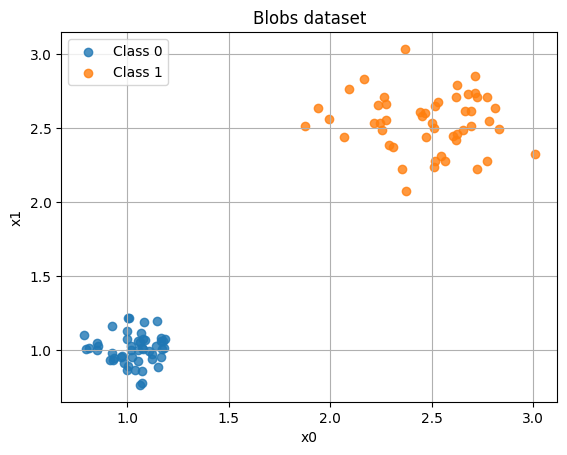

w = [0.89418064 1.01994712]
b = -3.2414880642092894


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Step 1: load the blob dataset.
# The first CSV column is only an index, so we keep columns 1 and 2 as features and the last column as labels.
blobs = np.loadtxt("data/blobs.csv", delimiter=",", skiprows=1)
X_blobs = blobs[:, 1:3]
y_blobs = blobs[:, 3].astype(int)

# Step 2: inspect the geometry of the two classes before training the classifier.
plt.scatter(X_blobs[y_blobs == 0, 0], X_blobs[y_blobs == 0, 1], label="Class 0", alpha=0.8)
plt.scatter(X_blobs[y_blobs == 1, 0], X_blobs[y_blobs == 1, 1], label="Class 1", alpha=0.8)
plt.xlabel("x0")
plt.ylabel("x1")
plt.title("Blobs dataset")
plt.legend()
plt.grid()
plt.show()

# Step 3: train a linear SVC with C = 1.
# A linear kernel is appropriate here because the scatter plot suggests near-perfect linear separation.
svc = SVC(kernel="linear", C=1)
svc.fit(X_blobs, y_blobs)

# Step 4: extract the separating hyperplane parameters from the fitted model.
# For a linear SVC, sklearn exposes them directly as coef_ and intercept_.
w = svc.coef_[0]
b = svc.intercept_[0]

print("w =", w)
print("b =", b)

## 2.2.3 Separating Hyperplane and Margin

> Task: Plot the separating hyperplane and the two parallel margin lines that pass through the support vectors. Then compute the geometric margin distance implied by $\mathbf{x}^{(i)\top}\mathbf{w} + b = \pm 1$.

> Pipeline schematic
1. Reuse the trained linear SVC from 2.2.2.
2. Highlight the support vectors on top of the scatter plot.
3. Draw the decision boundary $\mathbf{x}^\top \mathbf{w} + b = 0$.
4. Draw the two translated hyperplanes $\mathbf{x}^\top \mathbf{w} + b = \pm 1$.
5. Compute both the half-margin $1 / \lVert \mathbf{w} \rVert$ and the full margin width $2 / \lVert \mathbf{w} \rVert$.

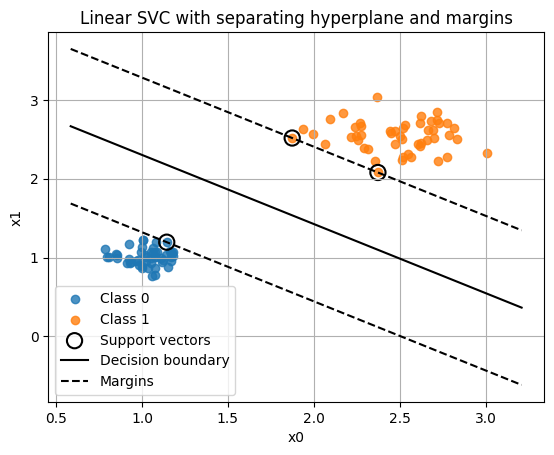

w = [0.89418064 1.01994712]
b = -3.2414880642092894
Distance from hyperplane to each margin = 0.7372396002977353
Total margin width = 1.4744792005954706


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Step 1: load the same blobs dataset used in 2.2.2.
blobs = np.loadtxt("data/blobs.csv", delimiter=",", skiprows=1)
X_blobs = blobs[:, 1:3]
y_blobs = blobs[:, 3].astype(int)

# Step 2: fit the same linear SVC so the margin visualization is consistent with the previous cell.
svc = SVC(kernel="linear", C=1)
svc.fit(X_blobs, y_blobs)

# Step 3: extract the model parameters and support vectors.
# The support vectors are the samples that define the maximum-margin solution.
w = svc.coef_[0]
b = svc.intercept_[0]
support_vectors = svc.support_vectors_

# Step 4: draw the dataset and highlight the support vectors.
plt.scatter(X_blobs[y_blobs == 0, 0], X_blobs[y_blobs == 0, 1], label="Class 0", alpha=0.8)
plt.scatter(X_blobs[y_blobs == 1, 0], X_blobs[y_blobs == 1, 1], label="Class 1", alpha=0.8)
plt.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=120,
    facecolors="none",
    edgecolors="k",
    linewidths=1.5,
    label="Support vectors",
)

# Step 5: parameterize the separating line and the two margin lines.
# In 2D we can solve x^T w + b = c for x1 to draw the lines explicitly.
x0_vals = np.linspace(X_blobs[:, 0].min() - 0.2, X_blobs[:, 0].max() + 0.2, 200)
decision_boundary = -(w[0] * x0_vals + b) / w[1]
margin_pos = -(w[0] * x0_vals + b - 1) / w[1]
margin_neg = -(w[0] * x0_vals + b + 1) / w[1]

plt.plot(x0_vals, decision_boundary, "k-", label="Decision boundary")
plt.plot(x0_vals, margin_pos, "k--", label="Margins")
plt.plot(x0_vals, margin_neg, "k--")

plt.xlabel("x0")
plt.ylabel("x1")
plt.title("Linear SVC with separating hyperplane and margins")
plt.legend()
plt.grid()
plt.show()

# Step 6: compute the geometric half-margin and full margin width.
# These follow directly from the canonical SVM constraints x^T w + b = ±1.
margin_to_boundary = 1 / np.linalg.norm(w)
margin_width = 2 / np.linalg.norm(w)

print("w =", w)
print("b =", b)
print("Distance from hyperplane to each margin =", margin_to_boundary)
print("Total margin width =", margin_width)

## 2.2.4 Linear SVC on `circles.csv`

> Task: Repeat 2.2.2 and 2.2.3 on `circles.csv` and decide whether the dataset is linearly separable in the original input space.

> Pipeline schematic
1. Load the circles dataset and visualize the two classes.
2. Train the same linear SVC as before.
3. Plot the resulting decision boundary and margins.
4. Inspect the support vectors and training accuracy.
5. Conclude whether a linear separator is sufficient.

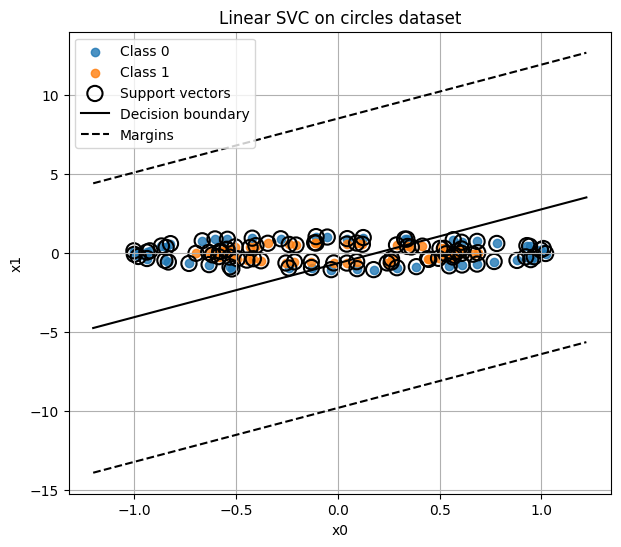

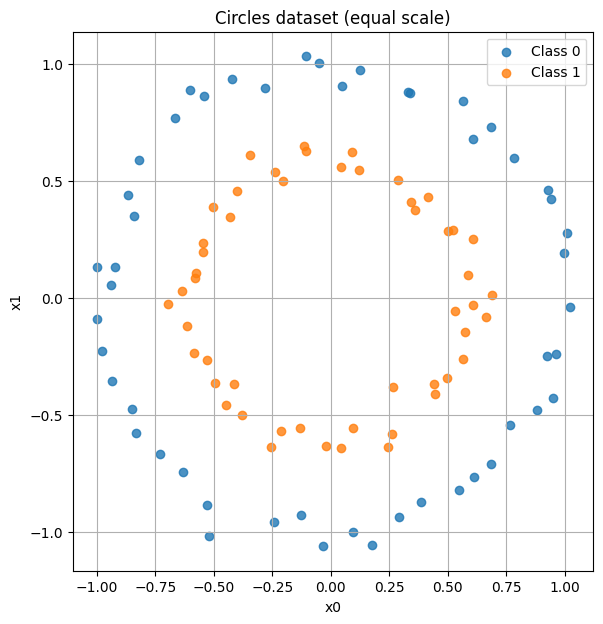

w = [-0.37269037  0.10905302]
b = 0.07123975036665797
Distance from hyperplane to each margin = 2.575210636184435
Total margin width = 5.15042127236887
Training accuracy = 0.51
Linearly separable in the given space? No


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Step 1: load the circles dataset.
circles = np.loadtxt("data/circles.csv", delimiter=",", skiprows=1)
X_circles = circles[:, 1:3]
y_circles = circles[:, 3].astype(int)

# Step 2: train the same linear SVC used before.
# We intentionally keep the linear kernel to test whether the original space is sufficient.
svc_circles = SVC(kernel="linear", C=1)
svc_circles.fit(X_circles, y_circles)

# Step 3: extract parameters, support vectors, and training accuracy.
w_circles = svc_circles.coef_[0]
b_circles = svc_circles.intercept_[0]
support_vectors_circles = svc_circles.support_vectors_
train_accuracy = svc_circles.score(X_circles, y_circles)

# Step 4: prepare the decision boundary and margins.
x0_vals = np.linspace(X_circles[:, 0].min() - 0.2, X_circles[:, 0].max() + 0.2, 200)
decision_boundary = -(w_circles[0] * x0_vals + b_circles) / w_circles[1]
margin_pos = -(w_circles[0] * x0_vals + b_circles - 1) / w_circles[1]
margin_neg = -(w_circles[0] * x0_vals + b_circles + 1) / w_circles[1]

# Step 5: first show the usual SVC plot with boundary and margins.
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_circles[y_circles == 0, 0], X_circles[y_circles == 0, 1], label="Class 0", alpha=0.8)
ax.scatter(X_circles[y_circles == 1, 0], X_circles[y_circles == 1, 1], label="Class 1", alpha=0.8)
ax.scatter(
    support_vectors_circles[:, 0],
    support_vectors_circles[:, 1],
    s=120,
    facecolors="none",
    edgecolors="k",
    linewidths=1.5,
    label="Support vectors",
)
ax.plot(x0_vals, decision_boundary, "k-", label="Decision boundary")
ax.plot(x0_vals, margin_pos, "k--", label="Margins")
ax.plot(x0_vals, margin_neg, "k--")
ax.set_xlabel("x0")
ax.set_ylabel("x1")
ax.set_title("Linear SVC on circles dataset")
ax.legend()
ax.grid()
plt.show()

# Step 6: now show only the data distribution with equal scaling.
# This keeps the circular geometry visible without the separating lines on top.
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(X_circles[y_circles == 0, 0], X_circles[y_circles == 0, 1], label="Class 0", alpha=0.8)
ax.scatter(X_circles[y_circles == 1, 0], X_circles[y_circles == 1, 1], label="Class 1", alpha=0.8)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x0")
ax.set_ylabel("x1")
ax.set_title("Circles dataset (equal scale)")
ax.legend()
ax.grid()
plt.show()

# Step 7: report geometric quantities and the training accuracy.
# Accuracy close to chance level is strong evidence that the dataset is not linearly separable here.
margin_to_boundary = 1 / np.linalg.norm(w_circles)
margin_width = 2 / np.linalg.norm(w_circles)

print("w =", w_circles)
print("b =", b_circles)
print("Distance from hyperplane to each margin =", margin_to_boundary)
print("Total margin width =", margin_width)
print("Training accuracy =", train_accuracy)
print("Linearly separable in the given space?", "No" if train_accuracy < 1.0 else "Yes")

## 2.2.5 Explicit Feature Transformation for `circles.csv`

> Task: Find a transformation $\phi : \mathbb{R}^2 \to \mathbb{R}^3$ such that `circles.csv` becomes linearly separable in the transformed space $\mathbf{x}'$. Then fit a linear SVC with $C = 100$ on the transformed dataset and visualize the result in the $(x_0, x_2')$ plane.

> Pipeline schematic
1. Construct a new third feature that captures the radial structure of the circles.
2. Transform the original samples into a 3D feature space.
3. Train a linear SVC on the transformed representation.
4. Visualize a 2D slice of the learned hyperplane by fixing $x_1 = 0$.
5. Check whether the transformed data is now perfectly separable.

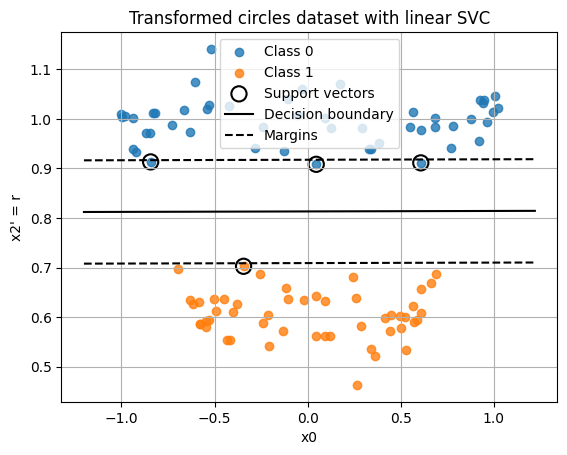

w = [ 9.06162640e-03 -9.67423495e-02 -9.59716500e+00]
b = 7.805461457164622
Training accuracy = 1.0
Linearly separable after transformation? Yes


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Step 1: load the circles dataset in its original 2D form.
circles = np.loadtxt("data/circles.csv", delimiter=",", skiprows=1)
X_circles = circles[:, 1:3]
y_circles = circles[:, 3].astype(int)

# Step 2: build an explicit feature map phi(x) = [x0, x1, r].
# The radial feature r = sqrt(x0^2 + x1^2) captures the circular structure that a linear model misses in 2D.
radius = np.sqrt(X_circles[:, 0] ** 2 + X_circles[:, 1] ** 2)
X_transformed = np.column_stack((X_circles[:, 0], X_circles[:, 1], radius))

# Step 3: fit a linear SVC in the transformed 3D space.
# A larger C is used here to enforce a nearly hard-margin separation once the classes become linearly separable.
svc_transformed = SVC(kernel="linear", C=100)
svc_transformed.fit(X_transformed, y_circles)

# Step 4: extract the hyperplane parameters in the transformed space.
w_transformed = svc_transformed.coef_[0]
b_transformed = svc_transformed.intercept_[0]
support_vectors_transformed = svc_transformed.support_vectors_
train_accuracy_transformed = svc_transformed.score(X_transformed, y_circles)

# Step 5: visualize a 2D slice of the 3D hyperplane using the coordinates (x0, x2').
# We fix x1 = 0 so we can solve the plane equation for x2' and draw it as a line.
plt.scatter(
    X_transformed[y_circles == 0, 0],
    X_transformed[y_circles == 0, 2],
    label="Class 0",
    alpha=0.8,
 )
plt.scatter(
    X_transformed[y_circles == 1, 0],
    X_transformed[y_circles == 1, 2],
    label="Class 1",
    alpha=0.8,
 )
plt.scatter(
    support_vectors_transformed[:, 0],
    support_vectors_transformed[:, 2],
    s=120,
    facecolors="none",
    edgecolors="k",
    linewidths=1.5,
    label="Support vectors",
)

x0_vals = np.linspace(
    X_transformed[:, 0].min() - 0.2,
    X_transformed[:, 0].max() + 0.2,
    200,
 )

# With x1 = 0, the hyperplane equation becomes w0*x0 + w2*x2' + b = 0.
decision_boundary = -(w_transformed[0] * x0_vals + b_transformed) / w_transformed[2]
margin_pos = -(w_transformed[0] * x0_vals + b_transformed - 1) / w_transformed[2]
margin_neg = -(w_transformed[0] * x0_vals + b_transformed + 1) / w_transformed[2]

plt.plot(x0_vals, decision_boundary, "k-", label="Decision boundary")
plt.plot(x0_vals, margin_pos, "k--", label="Margins")
plt.plot(x0_vals, margin_neg, "k--")

plt.xlabel("x0")
plt.ylabel("x2' = r")
plt.title("Transformed circles dataset with linear SVC")
plt.legend()
plt.grid()
plt.show()

# Step 6: report the learned parameters and confirm separability after the feature transformation.
print("w =", w_transformed)
print("b =", b_transformed)
print("Training accuracy =", train_accuracy_transformed)
print("Linearly separable after transformation?", "Yes" if train_accuracy_transformed == 1.0 else "No")

## 2.2.6 Polynomial-Kernel SVC

> Task: Fit an SVC with a polynomial kernel of degree 2 directly on the original 2D `circles.csv` dataset. Plot a heatmap of the predicted labels over $x_0, x_1 \in [-2, 2]$ and decide whether the resulting separator is linear in the original coordinates.

> Pipeline schematic
1. Train a nonlinear SVC through the kernel trick.
2. Evaluate the classifier on a dense 2D grid.
3. Convert the predictions into a heatmap of decision regions.
4. Overlay the original samples for geometric interpretation.
5. Compare the nonlinear boundary in input space with the linear-separability idea in feature space.

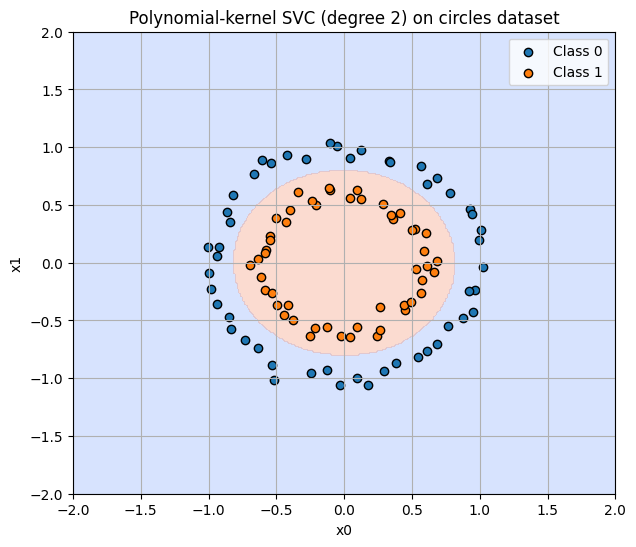

Training accuracy = 1.0
Is the separating hyperplane a linear function of x? No


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Step 1: load the original circles dataset again.
circles = np.loadtxt("data/circles.csv", delimiter=",", skiprows=1)
X_circles = circles[:, 1:3]
y_circles = circles[:, 3].astype(int)

# Step 2: fit a nonlinear SVC through the exact degree-2 polynomial kernel from the statement.
# In sklearn, this kernel is (gamma * x^T z + coef0)^degree, so we set gamma = 1 and coef0 = 1.
svc_poly = SVC(kernel="poly", degree=2, gamma=1.0, coef0=1.0, C=1)
svc_poly.fit(X_circles, y_circles)

# Step 3: build a dense 2D grid over the plotting domain.
# We evaluate the classifier on this grid to turn its predictions into a heatmap of decision regions.
x0_vals = np.linspace(-2, 2, 300)
x1_vals = np.linspace(-2, 2, 300)
xx0, xx1 = np.meshgrid(x0_vals, x1_vals)
grid_points = np.column_stack((xx0.ravel(), xx1.ravel()))

# Step 4: predict on the grid and reshape the outputs back to image form.
y_pred = svc_poly.predict(grid_points).reshape(xx0.shape)
train_accuracy_poly = svc_poly.score(X_circles, y_circles)

# Step 5: display the nonlinear decision regions together with the original samples.
plt.figure(figsize=(7, 6))
plt.contourf(xx0, xx1, y_pred, levels=[-0.5, 0.5, 1.5], cmap="coolwarm", alpha=0.35)
plt.scatter(X_circles[y_circles == 0, 0], X_circles[y_circles == 0, 1], label="Class 0", edgecolors="k")
plt.scatter(X_circles[y_circles == 1, 0], X_circles[y_circles == 1, 1], label="Class 1", edgecolors="k")
plt.xlabel("x0")
plt.ylabel("x1")
plt.title("Polynomial-kernel SVC (degree 2) on circles dataset")
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.legend()
plt.grid()
plt.show()

# Step 6: summarize the outcome in plain text.
print("Training accuracy =", train_accuracy_poly)
print("Is the separating hyperplane a linear function of x? No")

## 2.2.7 Implicit Feature Map of the Degree-2 Polynomial Kernel

> Task: For the kernel $k(\mathbf{x}^{(i)}, \mathbf{x}^{(j)}) = (\mathbf{x}^{(i)\top}\mathbf{x}^{(j)} + 1)^2$, derive the explicit feature map $\mathbf{x}' = \phi(\mathbf{x})$ for $\mathbf{x} = [x_0, x_1]^\top$ and state the transformed dimension $d'$.

The derivation is included in the report.

# Problem 2.3

> Goal: study kernel ridge regression in dual form and compare polynomial and RBF kernels on the 1D regression dataset.

## 2.3.1 Matrix Identity for the Dual Formulation

> Task: Show that the inverse in Equation (2.3.2) can be written in the data domain instead of the feature domain by proving

> $$
(X^\top X + \lambda I_d)^{-1} X^\top = X^\top (X X^\top + \lambda I_n)^{-1}.
$$

The proof is provided in the report.

## 2.3.2 Kernel Ridge Regression with a Polynomial Kernel

> Task: Use the matrix identity from 2.3.1 to rewrite ridge regression so the input vectors only appear through inner products. Then implement the estimator for the polynomial kernel

> $$
k(\mathbf{x}^{(i)}, \mathbf{x}^{(j)}) = (\mathbf{x}^{(i)\top} \mathbf{x}^{(j)} + 1)^m.
$$

> Pipeline schematic
1. Define the kernel function $k(\cdot, \cdot)$.
2. Build the training kernel matrix $K$.
3. Add ridge regularization in kernel space.
4. Solve for the dual coefficients $\boldsymbol{\alpha}$.
5. Predict test values by evaluating the kernel between test and training points.

In [6]:
import numpy as np

# Step 1: define the polynomial kernel k(x_i, x_j) = (x_i^T x_j + 1)^m.
# The +1 term acts like a bias and ensures that lower-order terms are included in the expansion.
def poly_kernel(X1, X2, m):
    return (X1 @ X2.T + 1) ** m

# Step 2: implement kernel ridge regression in dual form.
# In the dual view, the training data only appears through kernel evaluations, never through an explicit feature map.
def kernel_ridge_predict(X_train, y, X_test, lam, m):
    # Build the training kernel matrix K_ij = k(x_i, x_j).
    K = poly_kernel(X_train, X_train, m)

    # Add ridge regularization in kernel space to stabilize the linear system.
    n = K.shape[0]
    K_reg = K + lam * np.eye(n)

    # Solve for the dual coefficients alpha instead of primal weights.
    alpha = np.linalg.solve(K_reg, y)

    # Predict by comparing every test point against all training points through the same kernel.
    K_test = poly_kernel(X_test, X_train, m)
    y_pred = K_test @ alpha

    return y_pred

## 2.3.3 Polynomial-Kernel Regression on the 1D Dataset

> Task: Fit the regressor from 2.3.2 to the 1D regression dataset using $m \in \{1,2,3,10\}$ and plot predictions for $x \in [0,2]$. Also analyze the effect of different regularization strengths.

> Pipeline schematic
1. Load the 1D regression training set.
2. Define a dense prediction grid on $[0,2]$.
3. Compare several polynomial degrees $m$.
4. For each degree, compare several regularization values $\lambda$.
5. Interpret underfitting, overfitting, and smoothing effects.

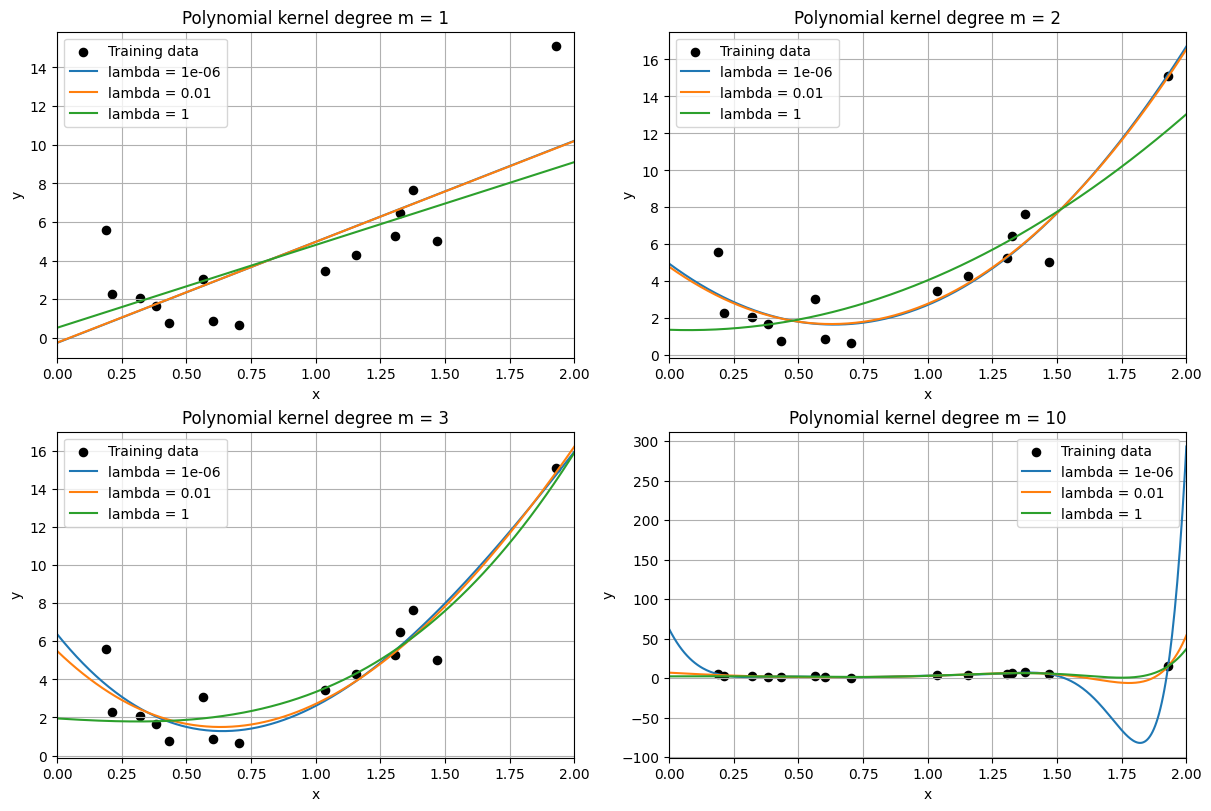

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: load the 1D regression training set.
# We reshape x into a column vector so the kernel functions can use matrix multiplication consistently.
train_data = np.loadtxt("data/regression_train.csv", delimiter=",", skiprows=1)
X_train = train_data[:, 0:1]
y_train = train_data[:, 1]

# Step 2: define a dense prediction grid on the full interval requested in the exercise.
x_plot = np.linspace(0, 2, 400).reshape(-1, 1)

# Step 3: choose the model complexities and regularization strengths to compare.
degrees = [1, 2, 3, 10]
lambda_vals = [1e-6, 1e-2, 1.0]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

for axis, m in zip(axes.ravel(), degrees):
    # Plot the training points first so every fitted curve can be interpreted against the observed data.
    axis.scatter(X_train[:, 0], y_train, color="black", s=35, label="Training data")

    # For a fixed degree m, varying lambda isolates the effect of regularization.
    for lam in lambda_vals:
        y_plot = kernel_ridge_predict(X_train, y_train, x_plot, lam, m)
        axis.plot(x_plot[:, 0], y_plot, label=f"lambda = {lam:g}")

    axis.set_title(f"Polynomial kernel degree m = {m}")
    axis.set_xlabel("x")
    axis.set_ylabel("y")
    axis.set_xlim(0, 2)
    axis.grid()
    axis.legend()

plt.show()

## 2.3.4 RBF-Kernel Regression on the 1D Dataset

> Task: Repeat 2.3.3 with the RBF kernel

> $$
k(\mathbf{x}^{(i)}, \mathbf{x}^{(j)}) = \exp\left(-\frac{\lVert \mathbf{x}^{(i)} - \mathbf{x}^{(j)} \rVert^2}{2\, ls^2}\right).
$$

> Briefly interpret the role of the kernel parameter $ls$.

> Pipeline schematic
1. Replace the polynomial kernel by an RBF kernel.
2. Compare several length scales $ls$.
3. For each length scale, compare several regularization values $\lambda$.
4. Visualize how local or global the fitted curves become.
5. Relate the effect of $ls$ to model flexibility and smoothness.

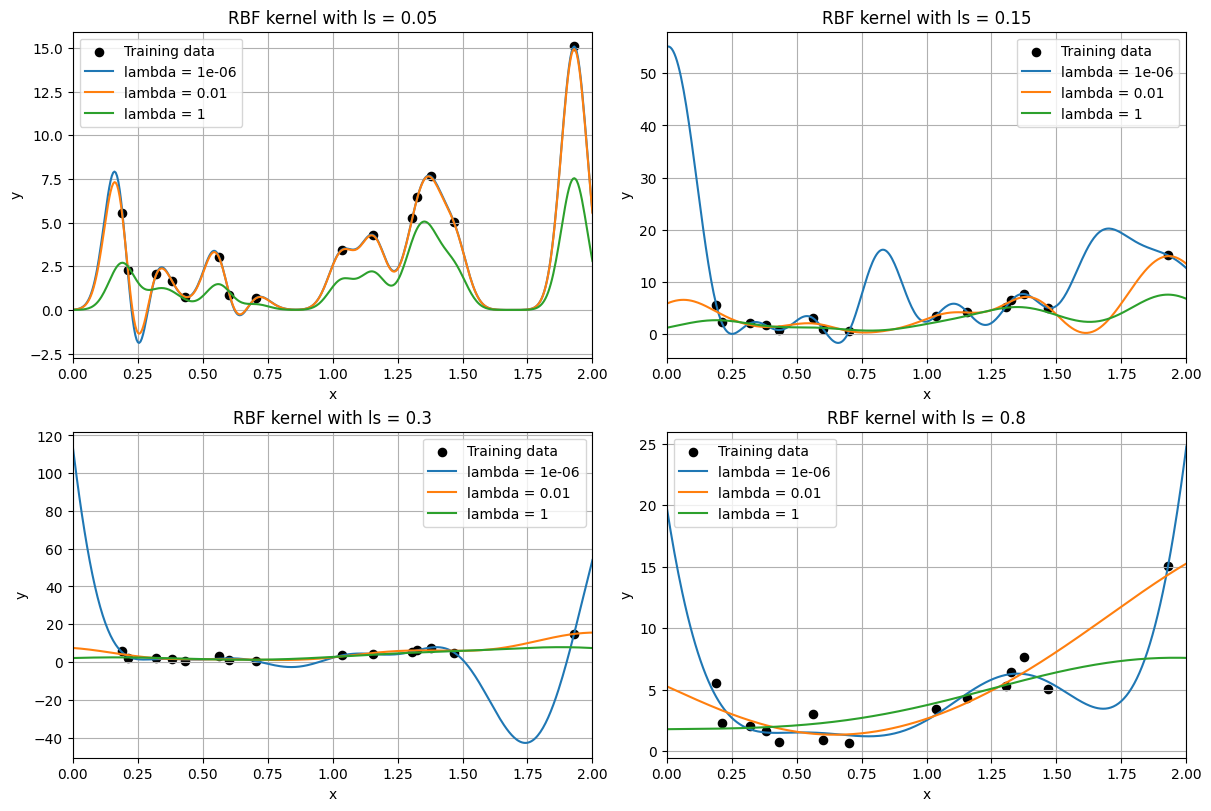

Small ls gives a very local and flexible fit; large ls gives a smoother, more global fit.


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: load the same 1D regression dataset used in the polynomial-kernel experiment.
train_data = np.loadtxt("data/regression_train.csv", delimiter=",", skiprows=1)
X_train = train_data[:, 0:1]
y_train = train_data[:, 1]

# Step 2: define the RBF kernel.
# The length scale ls controls how quickly the influence of one point decays with distance.
def rbf_kernel(X1, X2, ls):
    sq_dist = (X1[:, None, :] - X2[None, :, :]) ** 2
    sq_dist = np.sum(sq_dist, axis=2)
    return np.exp(-sq_dist / (2 * ls**2))

# Step 3: implement kernel ridge regression with the RBF kernel.
# The structure is the same as before; only the kernel matrix changes.
def kernel_ridge_predict_rbf(X_train, y, X_test, lam, ls):
    K = rbf_kernel(X_train, X_train, ls)
    n = K.shape[0]
    alpha = np.linalg.solve(K + lam * np.eye(n), y)
    K_test = rbf_kernel(X_test, X_train, ls)
    return K_test @ alpha

# Step 4: define the prediction grid and the hyperparameter combinations to compare.
x_plot = np.linspace(0, 2, 400).reshape(-1, 1)
length_scales = [0.05, 0.15, 0.3, 0.8]
lambda_vals = [1e-6, 1e-2, 1.0]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

for axis, ls in zip(axes.ravel(), length_scales):
    # We keep the training scatter in each subplot so local and global fits are easy to compare.
    axis.scatter(X_train[:, 0], y_train, color="black", s=35, label="Training data")

    # For a fixed length scale, lambda controls how much we smooth the kernel solution.
    for lam in lambda_vals:
        y_plot = kernel_ridge_predict_rbf(X_train, y_train, x_plot, lam, ls)
        axis.plot(x_plot[:, 0], y_plot, label=f"lambda = {lam:g}")

    axis.set_title(f"RBF kernel with ls = {ls}")
    axis.set_xlabel("x")
    axis.set_ylabel("y")
    axis.set_xlim(0, 2)
    axis.grid()
    axis.legend()

plt.show()

# Step 5: summarize the qualitative interpretation of the length-scale parameter.
print("Small ls gives a very local and flexible fit; large ls gives a smoother, more global fit.")

## 2.3.5 Implicit Feature Map of the Scalar RBF Kernel

> Task: Derive the analytical expression of the feature mapping $x_i \mapsto \phi_i = \phi(x_i)$ implied by the RBF kernel in the scalar case $d = 1$. State the transformed dimension $d'$.

> Hint: use the exponential series

> $$
e^t = \sum_{n=0}^{\infty} \frac{t^n}{n!}.
$$

The derivation is included in the report.

# Problem 2.4

> Goal: study probability calibration for a random forest classifier through reliability diagrams, log-loss, and Platt scaling.

## 2.4.1 Train, Calibration, and Test Split

> Task: Load `calibration.csv` with `pandas`. First split the dataset into `Ttrain_full` and `Ttest` with `test_size = 0.2` and `random_state = 256`. Then split `Ttrain_full` into `Ttrain` and `Tcal` with the same `test_size` and `random_state`.

> Pipeline schematic
1. Load the calibration dataset into a dataframe.
2. Create the held-out test set.
3. Split the remaining data into training and calibration subsets.
4. Check the sizes of all resulting partitions.

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Pipeline: load the calibration dataset, create a held-out test split, then reserve part of the remaining data for probability calibration.


# Step 1: load the dataset as a dataframe.
# Keeping the data in pandas makes it easier to preserve feature names and manipulate splits later on.
calibration_data = pd.read_csv("data/calibration.csv")
print(calibration_data.head())


# Step 2: create the outer train/test split.
# Ttest must stay untouched until evaluation so that all reported metrics reflect generalization performance.
Ttrain_full, Ttest = train_test_split(
    calibration_data,
    test_size=0.2,
    random_state=256,
    shuffle=True,
 )


# Step 3: split the remaining data into training and calibration subsets.
# Tcal is kept separate from Ttrain because the calibration model should not be fit on the same data used to train the random forest.
Ttrain, Tcal = train_test_split(
    Ttrain_full,
    test_size=0.2,
    random_state=256,
    shuffle=True,
 )


# Step 4: verify the sizes of all splits.
# This quick sanity check confirms that the two-stage partitioning was applied as intended.
print(f"Full dataset size: {len(calibration_data)}")
print(f"Ttrain_full size: {len(Ttrain_full)}")
print(f"Ttest size: {len(Ttest)}")
print(f"Ttrain size: {len(Ttrain)}")
print(f"Tcal size: {len(Tcal)}")

   Unnamed: 0       x_0       x_1       x_2       x_3       x_4       x_5  \
0           0 -1.309339  0.352901 -0.939590  1.172544  0.258508  2.953020   
1           1 -0.900485 -0.109227 -1.114314 -0.143735  1.624058 -2.706003   
2           2 -3.123054 -2.584957 -1.171681 -1.189867  0.522743 -2.039017   
3           3  0.215643 -2.999881 -0.070790 -1.580482  1.765921 -1.636937   
4           4 -2.012175  3.446738 -1.364566  1.753379  1.468406 -2.681456   

        x_6       x_7       x_8  ...      x_11      x_12      x_13      x_14  \
0  0.563973 -0.170768 -0.216582  ... -0.906504  3.236358 -0.085858 -2.665934   
1 -1.889569 -1.044811  0.684816  ...  0.054862  4.136268  3.241079 -0.188887   
2  2.668373  1.161253  4.201122  ...  1.036024 -4.931341 -1.706812  4.147973   
3  0.875122  2.463446  0.835953  ... -0.383986 -2.239031  1.315837  5.534653   
4  2.167164 -0.752500  0.941848  ...  1.587833  3.044144 -1.371052 -5.279869   

       x_15      x_16      x_17      x_18      x_19  y  

## 2.4.2 Random Forest on `Ttrain`

> Task: Fit a random forest classifier to `Ttrain` and evaluate it on `Ttest`. Report the accuracy, plot the confusion matrix, and compute Precision, Recall, and F1-score.


> Pipeline schematic
1. Extract features and labels from the training and test sets.
2. Train a random forest classifier on `Ttrain`.
3. Predict class labels on `Ttest`.
4. Compute accuracy and the confusion matrix.
5. Derive Precision, Recall, and F1-score from the predictions.

Accuracy on Ttest: 0.9445
Precision: 0.9365
Recall: 0.9558
F1-score: 0.9461
Confusion matrix:
[[1830  132]
 [  90 1948]]


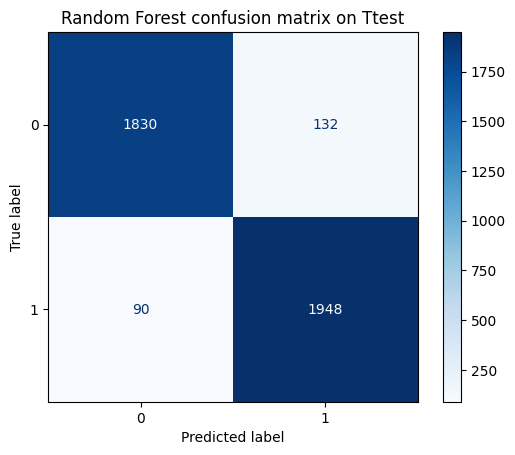

In [9]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
 )

# Pipeline: extract the supervised learning inputs, train a random forest on Ttrain, evaluate it on Ttest, and summarize the classification performance.


# Step 1: separate features and labels.
# We keep all columns starting with x_ as inputs and y as the binary target.
feature_cols = [col for col in Ttrain.columns if col.startswith("x_")]
X_train = Ttrain[feature_cols]
y_train = Ttrain["y"]
X_test = Ttest[feature_cols]
y_test = Ttest["y"]


# Step 2: fit the random forest classifier.
# The fixed random_state makes the result reproducible, which is useful when comparing calibrated and uncalibrated models later on.
rf = RandomForestClassifier(random_state=256)
rf.fit(X_train, y_train)


# Step 3: predict the class labels on the held-out test set.
# At this stage we only use hard class predictions, not probabilities.
y_pred = rf.predict(X_test)


# Step 4: compute the standard classification metrics.
# Accuracy measures overall correctness, while precision/recall/F1 reveal how the classifier behaves on the positive class.
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy on Ttest: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print("Confusion matrix:")
print(cm)


# Step 5: visualize the confusion matrix.
# This makes the balance between false positives and false negatives easier to inspect than raw numbers alone.
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("Random Forest confusion matrix on Ttest")
plt.grid(False)
plt.show()

## 2.4.3 Reliability Diagram of the Uncalibrated Classifier

> Task: Predict the class probabilities on `Ttest` using `RandomForestClassifier.predict_proba()`. Build a dataframe with the true labels and the predicted probability of the positive class, assign each sample to one of 10 bins using `np.linspace(0, 1, 11)` and `pandas.cut()`, then construct the reliability diagram. Also compute the log-loss on `Ttest`.

> Pipeline schematic
1. Predict positive-class probabilities on the test set.
2. Store labels, probabilities, and probability bins in a dataframe.
3. Aggregate each bin by mean predicted probability and fraction of positives.
4. Plot the reliability diagram together with the perfectly calibrated diagonal.
5. Compute the log-loss for the uncalibrated classifier.

   y_true  y_proba_pos            bin
0       1         0.68     (0.6, 0.7]
1       0         0.34     (0.3, 0.4]
2       1         0.66     (0.6, 0.7]
3       0         0.06  (-0.001, 0.1]
4       1         0.98     (0.9, 1.0]

             bin  mean_predicted_probability  fraction_of_positives  \
0  (-0.001, 0.1]                    0.054454               0.000000   
1     (0.1, 0.2]                    0.150437               0.006237   
2     (0.2, 0.3]                    0.250769               0.022436   
3     (0.3, 0.4]                    0.350746               0.131579   
4     (0.4, 0.5]                    0.457443               0.284091   
5     (0.5, 0.6]                    0.555050               0.633663   
6     (0.6, 0.7]                    0.657529               0.886275   
7     (0.7, 0.8]                    0.757488               0.956522   
8     (0.8, 0.9]                    0.859160               0.987786   
9     (0.9, 1.0]                    0.949043               0.

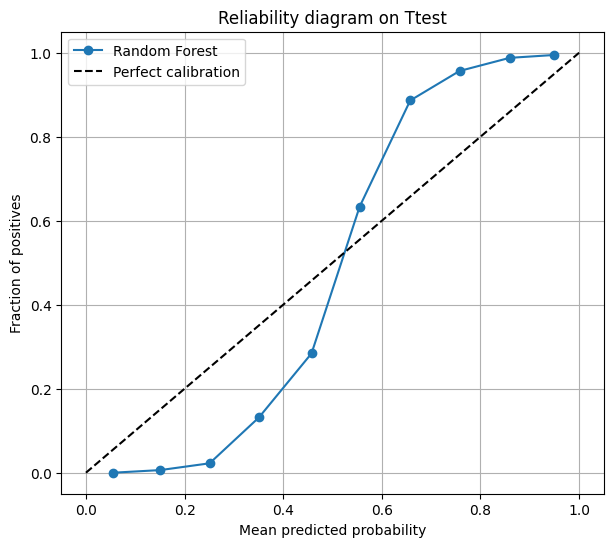

Log-loss on Ttest: 0.2495
The classifier is not perfectly calibrated because the curve deviates from the diagonal across several bins.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss

# Pipeline: predict uncalibrated probabilities on Ttest, organize them into bins, build the reliability diagram, and compute the log-loss.


# Step 1: compute the positive-class probabilities on the test set.
# Reliability diagrams use probabilities rather than hard labels because calibration is about whether confidence matches observed frequencies.
X_test = Ttest[feature_cols]
y_test = Ttest["y"]
y_proba = rf.predict_proba(X_test)[:, 1]


# Step 2: store the true labels and predicted probabilities in one dataframe.
# Keeping everything together makes the subsequent grouping by bins straightforward.
test_proba_df = pd.DataFrame({
    "y_true": y_test.to_numpy(),
    "y_proba_pos": y_proba,
})


# Step 3: assign each sample to one of 10 probability bins.
# Uniform bins over [0, 1] are used so the manual diagram matches the specification and the later sklearn helper call.
bin_boundaries = np.linspace(0, 1, 11)
test_proba_df["bin"] = pd.cut(
    test_proba_df["y_proba_pos"],
    bins=bin_boundaries,
    include_lowest=True,
 )


# Step 4: aggregate each bin into the quantities needed for the reliability diagram.
# The x-coordinate is the mean predicted probability in the bin, while the y-coordinate is the fraction of positives, i.e. the mean of the true labels.
reliability_df = (
    test_proba_df.groupby("bin", observed=False)
    .agg(
        mean_predicted_probability=("y_proba_pos", "mean"),
        fraction_of_positives=("y_true", "mean"),
        samples_in_bin=("y_true", "size"),
    )
    .dropna()
    .reset_index()
 )

print(test_proba_df.head())
print()
print(reliability_df)


# Step 5: plot the reliability diagram against the perfectly calibrated diagonal.
# Points on the diagonal correspond to probabilities that match the empirical frequency of the positive class.
plt.figure(figsize=(7, 6))
plt.plot(
    reliability_df["mean_predicted_probability"],
    reliability_df["fraction_of_positives"],
    marker="o",
    label="Random Forest",
)
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Reliability diagram on Ttest")
plt.legend()
plt.grid()
plt.show()


# Step 6: compute the log-loss on Ttest.
# Log-loss penalizes confident wrong probabilities, so it is useful for comparing probabilistic predictions before and after calibration.
test_log_loss = log_loss(y_test, y_proba)
print(f"Log-loss on Ttest: {test_log_loss:.4f}")
print("The classifier is not perfectly calibrated because the curve deviates from the diagonal across several bins.")

## 2.4.4 Reliability Diagram with `CalibrationDisplay`

> Task: Recreate the reliability diagram in one step using `sklearn.calibration.CalibrationDisplay.from_estimator()` with `n_bins = 10`, and compare the result with the manual diagram from 2.4.3.


> Pipeline schematic
1. Use the already trained random forest from 2.4.2.
2. Call `CalibrationDisplay.from_estimator()` on `Ttest`.
3. Set the number of bins to 10.
4. Compare the resulting plot with the manually computed reliability diagram.

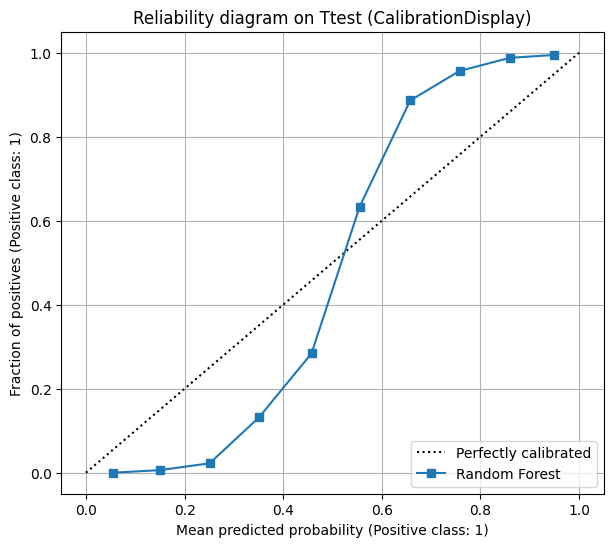

The overall shape is consistent with the manual reliability diagram from 2.4.3.
The sklearn helper mainly automates the same binning and averaging procedure.


In [11]:
import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay

# Pipeline: reproduce the reliability diagram with sklearn's built-in helper and compare it with the manual construction from 2.4.3.


# Step 1: create the reliability diagram directly from the estimator.
# This helper performs the same core operations as before—probability prediction, binning, and aggregation—but wraps them into a single call.
fig, ax = plt.subplots(figsize=(7, 6))
CalibrationDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    n_bins=10,
    strategy="uniform",
    ax=ax,
    name="Random Forest",
)


# Step 2: style the plot and compare it conceptually with the manual version.
# Using the same number of bins makes the two diagrams directly comparable.
ax.set_title("Reliability diagram on Ttest (CalibrationDisplay)")
ax.grid()
plt.show()

print("The overall shape is consistent with the manual reliability diagram from 2.4.3.")
print("The sklearn helper mainly automates the same binning and averaging procedure.")

## 2.4.5 Platt Scaling with `CalibratedClassifierCV`

> Task: Calibrate the random forest classifier with Platt scaling, which corresponds to logistic regression on the uncalibrated scores without an explicit regularization term. Use `sklearn.calibration.CalibratedClassifierCV()` with `method = "sigmoid"`, fit the calibrator on `Tcal`, predict calibrated probabilities on `Ttest`, derive class labels, and compare the calibrated classifier against the uncalibrated one in terms of accuracy, log-loss, and reliability diagram.


> Pipeline schematic
1. Keep the random forest from 2.4.2 fixed.
2. Fit a sigmoid calibration model on the independent calibration set `Tcal`.
3. Predict calibrated probabilities on `Ttest`.
4. Derive class labels from the calibrated probabilities.
5. Compare accuracy, log-loss, and the reliability diagram before and after calibration.

Uncalibrated accuracy on Ttest: 0.9445
Calibrated accuracy on Ttest: 0.9445
Uncalibrated log-loss on Ttest: 0.2495
Calibrated log-loss on Ttest: 0.1502
Calibration changes the quality of the probabilities much more than the hard class predictions.


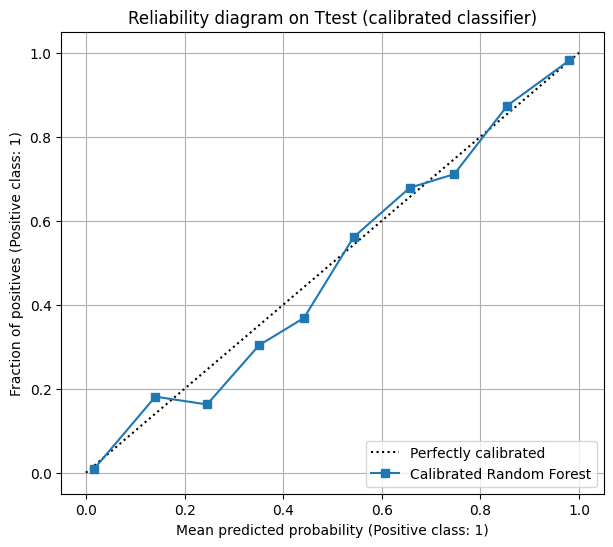

In [12]:
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import accuracy_score, log_loss

# Pipeline: fit a Platt-scaling calibrator on Tcal, evaluate the calibrated classifier on Ttest, and compare its probabilities with those of the uncalibrated random forest.


# Step 1: prepare the calibration and test sets.
# Tcal is the independent dataset used to learn the post-processing map from uncalibrated to calibrated probabilities.
X_cal = Tcal[feature_cols]
y_cal = Tcal["y"]
X_test = Ttest[feature_cols]
y_test = Ttest["y"]


# Step 2: fit the Platt-scaling model on top of the already trained random forest.
# In recent sklearn versions, a prefit estimator is wrapped with FrozenEstimator instead of passing cv="prefit" directly.
calibrated_rf = CalibratedClassifierCV(FrozenEstimator(rf), method="sigmoid")
calibrated_rf.fit(X_cal, y_cal)


# Step 3: predict calibrated probabilities and derive class labels.
# The 0.5 threshold is used here only to compare hard-label accuracy with the original classifier; the main goal of calibration is to improve the probabilities themselves.
y_proba_cal = calibrated_rf.predict_proba(X_test)[:, 1]
y_pred_cal = (y_proba_cal >= 0.5).astype(int)


# Step 4: compare the calibrated and uncalibrated models through accuracy and log-loss.
# Accuracy may stay unchanged after calibration, while log-loss often improves because the probabilities become more realistic.
calibrated_accuracy = accuracy_score(y_test, y_pred_cal)
calibrated_log_loss = log_loss(y_test, y_proba_cal)

print(f"Uncalibrated accuracy on Ttest: {accuracy:.4f}")
print(f"Calibrated accuracy on Ttest: {calibrated_accuracy:.4f}")
print(f"Uncalibrated log-loss on Ttest: {test_log_loss:.4f}")
print(f"Calibrated log-loss on Ttest: {calibrated_log_loss:.4f}")
print("Calibration changes the quality of the probabilities much more than the hard class predictions.")


# Step 5: visualize the reliability diagram of the calibrated classifier.
# If calibration works well, the curve should move closer to the diagonal than in the uncalibrated case.
fig, ax = plt.subplots(figsize=(7, 6))
CalibrationDisplay.from_estimator(
    calibrated_rf,
    X_test,
    y_test,
    n_bins=10,
    strategy="uniform",
    ax=ax,
    name="Calibrated Random Forest",
)
ax.set_title("Reliability diagram on Ttest (calibrated classifier)")
ax.grid()
plt.show()